In [ ]:
!pip install -q --force-reinstall "protobuf==5.29.5"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 19.1 MB/s eta 0:00:00


In [ ]:
import os
import gc
import time
import tarfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
DATA_DIR = "/content/oxford_pet"

os.makedirs(DATA_DIR, exist_ok=True)

images_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
annotations_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

images_tar = "/content/images.tar.gz"
annotations_tar = "/content/annotations.tar.gz"

if not os.path.exists("/content/oxford_pet/images"):
    print("Downloading images...")
    urllib.request.urlretrieve(images_url, images_tar)

    print("Extracting images...")
    with tarfile.open(images_tar, "r:gz") as tar:
        tar.extractall("/content/oxford_pet")

if not os.path.exists("/content/oxford_pet/annotations"):
    print("Downloading annotations...")
    urllib.request.urlretrieve(annotations_url, annotations_tar)

    print("Extracting annotations...")
    with tarfile.open(annotations_tar, "r:gz") as tar:
        tar.extractall("/content/oxford_pet")

print("Dataset ready!")

Dataset ready!


In [ ]:
annotation_file = os.path.join(
    DATA_DIR,
    "annotations",
    "trainval.txt"
)

image_dir = os.path.join(
    DATA_DIR,
    "images"
)

image_paths = []
labels = []

with open(annotation_file, "r") as f:

    for line in f:

        parts = line.strip().split()

        image_name = parts[0]
        class_id = int(parts[1])

        image_path = os.path.join(
            image_dir,
            image_name + ".jpg"
        )

        if os.path.exists(image_path):

            image_paths.append(image_path)

            # Convert labels from 1-37 to 0-36
            labels.append(class_id - 1)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Number of images:", len(image_paths))
print("Number of labels:", len(labels))
print("Number of classes:", len(np.unique(labels)))

Number of images: 3680
Number of labels: 3680
Number of classes: 37


In [ ]:
test_annotation_file = os.path.join(
    DATA_DIR,
    "annotations",
    "test.txt"
)

test_paths = []
test_labels = []

with open(test_annotation_file, "r") as f:

    for line in f:

        parts = line.strip().split()

        image_name = parts[0]
        class_id = int(parts[1])

        image_path = os.path.join(
            image_dir,
            image_name + ".jpg"
        )

        if os.path.exists(image_path):

            test_paths.append(image_path)
            test_labels.append(class_id - 1)

test_paths = np.array(test_paths)
test_labels = np.array(test_labels)

print("Test images:", len(test_paths))
print("Test labels:", len(test_labels))
print("Test classes:", len(np.unique(test_labels)))

Test images: 3669
Test labels: 3669
Test classes: 37


In [ ]:
IMG_SIZE = 224

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = tf.keras.applications.mobilenet_v2.preprocess_input(
        image
    )

    return image, label

In [ ]:
def create_dataset(paths, labels, batch_size=16, shuffle=False):

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(batch_size)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [ ]:
configs = {

    "C1": {
        "learning_rate": 0.001,
        "dropout": 0.25
    },

    "C2": {
        "learning_rate": 0.0001,
        "dropout": 0.25
    },

    "C3": {
        "learning_rate": 0.0001,
        "dropout": 0.50
    }

}

configs

{'C1': {'learning_rate': 0.001, 'dropout': 0.25},
 'C2': {'learning_rate': 0.0001, 'dropout': 0.25},
 'C3': {'learning_rate': 0.0001, 'dropout': 0.5}}

In [ ]:
NUM_CLASSES = 37

def create_model(
    learning_rate=0.0001,
    dropout_rate=0.25
):

    base_model = tf.keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze pretrained layers
    base_model.trainable = False

    inputs = tf.keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dropout(
        dropout_rate
    )(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model

In [ ]:
N_SPLITS = 5

# Keep these small because of Colab limitations
EPOCHS = 3
BATCH_SIZE = 16

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

print("Number of folds:", N_SPLITS)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

Number of folds: 5
Epochs: 3
Batch size: 16


In [ ]:
cv_results = []

for config_name, config in configs.items():

    print("\n")
    print("=" * 60)
    print("CONFIGURATION:", config_name)
    print("Learning Rate:", config["learning_rate"])
    print("Dropout:", config["dropout"])
    print("=" * 60)

    fold_accuracies = []

    for fold, (train_index, val_index) in enumerate(
        kf.split(image_paths),
        start=1
    ):

        print("\n")
        print("-" * 50)
        print("Fold:", fold)
        print("-" * 50)

        train_paths = image_paths[train_index]
        train_labels = labels[train_index]

        val_paths = image_paths[val_index]
        val_labels = labels[val_index]

        train_dataset = create_dataset(
            train_paths,
            train_labels,
            batch_size=BATCH_SIZE,
            shuffle=True
        )

        val_dataset = create_dataset(
            val_paths,
            val_labels,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        # Clear previous model from memory
        tf.keras.backend.clear_session()
        gc.collect()

        model = create_model(
            learning_rate=config["learning_rate"],
            dropout_rate=config["dropout"]
        )

        start_time = time.time()

        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=EPOCHS,
            verbose=1
        )

        fold_time = time.time() - start_time

        best_val_accuracy = max(
            history.history["val_accuracy"]
        )

        fold_accuracies.append(
            best_val_accuracy
        )

        print(
            "\nFold",
            fold,
            "Best Validation Accuracy:",
            round(best_val_accuracy * 100, 2),
            "%"
        )

        print(
            "Fold training time:",
            round(fold_time, 2),
            "seconds"
        )

        # Delete everything from this fold
        del model
        del history
        del train_dataset
        del val_dataset

        tf.keras.backend.clear_session()
        gc.collect()

    mean_accuracy = np.mean(
        fold_accuracies
    )

    std_accuracy = np.std(
        fold_accuracies
    )

    cv_results.append({

        "Configuration": config_name,

        "Fold 1": fold_accuracies[0] * 100,

        "Fold 2": fold_accuracies[1] * 100,

        "Fold 3": fold_accuracies[2] * 100,

        "Fold 4": fold_accuracies[3] * 100,

        "Fold 5": fold_accuracies[4] * 100,

        "Mean Accuracy": mean_accuracy * 100,

        "SD": std_accuracy * 100

    })

    print("\n")
    print("Configuration:", config_name)

    print(
        "Mean CV Accuracy:",
        round(mean_accuracy * 100, 2),
        "%"
    )

    print(
        "Standard Deviation:",
        round(std_accuracy * 100, 2),
        "%"
    )



CONFIGURATION: C1
Learning Rate: 0.001
Dropout: 0.25


--------------------------------------------------
Fold: 1
--------------------------------------------------
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 31s 72ms/step - accuracy: 0.7171 - loss: 1.1136 - val_accuracy: 0.8764 - val_loss: 0.4298
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.9158 - loss: 0.2991 - val_accuracy: 0.9103 - val_loss: 0.3235
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9558 - loss: 0.1870 - val_accuracy: 0.8954 - val_loss: 0.2997

Fold 1 Best Validation Accuracy: 91.03 %
Fold training time: 50.93 seconds


--------------------------------------------------
Fold: 2
--------------------------------------------------
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 27s 101ms/step - accuracy: 0.7140 - loss: 1.1321 - val_accuracy: 0.8832 - val_loss: 0.4201
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.9181 - loss: 0.

In [ ]:
cv_df = pd.DataFrame(cv_results)

cv_df

,Configuration,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Accuracy,SD
0,C1,91.032606,91.168481,92.119563,88.586956,92.798913,91.141304,1.431216
1,C2,82.472825,82.880437,82.744563,79.755437,82.201087,82.010870,1.151609
2,C3,75.407606,79.211956,78.260869,73.233694,77.581519,76.739129,2.154122


In [ ]:
best_row = cv_df.loc[
    cv_df["Mean Accuracy"].idxmax()
]

best_config_name = best_row["Configuration"]

best_config = configs[
    best_config_name
]

print("Best Configuration:", best_config_name)

print(
    "Learning Rate:",
    best_config["learning_rate"]
)

print(
    "Dropout:",
    best_config["dropout"]
)

print(
    "Mean CV Accuracy:",
    round(best_row["Mean Accuracy"], 2),
    "%"
)

print(
    "CV Standard Deviation:",
    round(best_row["SD"], 2),
    "%"
)

Best Configuration: C1
Learning Rate: 0.001
Dropout: 0.25
Mean CV Accuracy: 91.14 %
CV Standard Deviation: 1.43 %


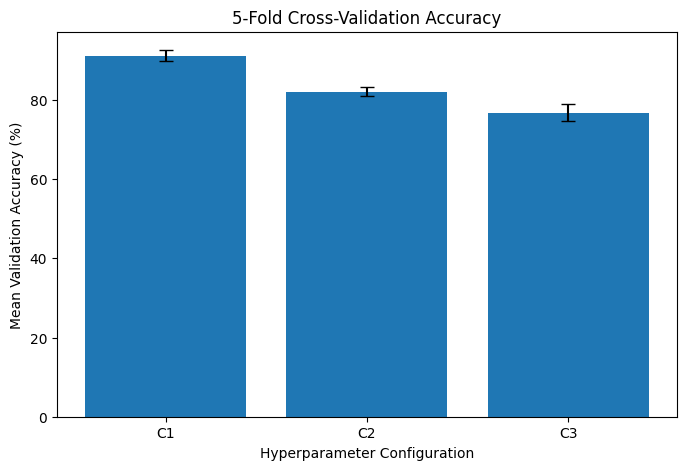

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    cv_df["Configuration"],
    cv_df["Mean Accuracy"],
    yerr=cv_df["SD"],
    capsize=5
)

plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy")

plt.show()

In [ ]:
full_train_dataset = create_dataset(
    image_paths,
    labels,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = create_dataset(
    test_paths,
    test_labels,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Datasets created.")

Datasets created.


In [ ]:
tf.keras.backend.clear_session()
gc.collect()

final_model = create_model(
    learning_rate=best_config["learning_rate"],
    dropout_rate=best_config["dropout"]
)

start_time = time.time()

final_history = final_model.fit(
    full_train_dataset,
    epochs=5,
    validation_split=None,
    verbose=1
)

training_time = time.time() - start_time

print(
    "\nFinal training time:",
    round(training_time, 2),
    "seconds"
)

Epoch 1/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.7408 - loss: 0.9961
Epoch 2/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9149 - loss: 0.2800
Epoch 3/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9465 - loss: 0.1895
Epoch 4/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9655 - loss: 0.1296
Epoch 5/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9802 - loss: 0.0897

Final training time: 55.08 seconds


In [ ]:
final_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,400,177 (9.16 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 94,796 (370.30 KB)

In [ ]:
num_parameters = final_model.count_params()

print(
    "Number of Parameters:",
    num_parameters
)

Number of Parameters: 2305381


In [ ]:
test_loss, test_accuracy = final_model.evaluate(
    test_dataset,
    verbose=1
)

print(
    "\nTest Loss:",
    test_loss
)

print(
    "Test Accuracy:",
    test_accuracy * 100,
    "%"
)

230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.8953 - loss: 0.3220

Test Loss: 0.32199159264564514
Test Accuracy: 89.533931016922 %


In [ ]:
y_probability = final_model.predict(
    test_dataset,
    verbose=1
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("Predictions generated.")

230/230 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step
Predictions generated.


In [ ]:
precision = precision_score(
    test_labels,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    test_labels,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    test_labels,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8982990633706049
Recall: 0.8953393295175798
F1 Score: 0.8951360596443284


In [ ]:
final_results = pd.DataFrame({

    "Metric": [

        "Mean CV Accuracy",

        "CV Standard Deviation",

        "Test Accuracy",

        "Precision",

        "Recall",

        "F1-score",

        "Training Time (seconds)",

        "Number of Parameters"

    ],

    "Value": [

        best_row["Mean Accuracy"],

        best_row["SD"],

        test_accuracy * 100,

        precision,

        recall,

        f1,

        training_time,

        num_parameters

    ]

})

final_results

,Metric,Value
0,Mean CV Accuracy,9.114130e+01
1,CV Standard Deviation,1.431216e+00
2,Test Accuracy,8.953393e+01
3,Precision,8.982991e-01
4,Recall,8.953393e-01
5,F1-score,8.951361e-01
6,Training Time (seconds),5.508246e+01
7,Number of Parameters,2.305381e+06


In [ ]:
print("\n")
print("=" * 50)
print("FINAL MODEL RESULTS")
print("=" * 50)

print(
    "Best Configuration:",
    best_config_name
)

print(
    "Mean CV Accuracy:",
    round(best_row["Mean Accuracy"], 2),
    "%"
)

print(
    "CV Standard Deviation:",
    round(best_row["SD"], 2),
    "%"
)

print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision, 4)
)

print(
    "Recall:",
    round(recall, 4)
)

print(
    "F1 Score:",
    round(f1, 4)
)

print(
    "Training Time:",
    round(training_time, 2),
    "seconds"
)

print(
    "Number of Parameters:",
    num_parameters
)



FINAL MODEL RESULTS
Best Configuration: C1
Mean CV Accuracy: 91.14 %
CV Standard Deviation: 1.43 %
Test Accuracy: 89.53 %
Precision: 0.8983
Recall: 0.8953
F1 Score: 0.8951
Training Time: 55.08 seconds
Number of Parameters: 2305381


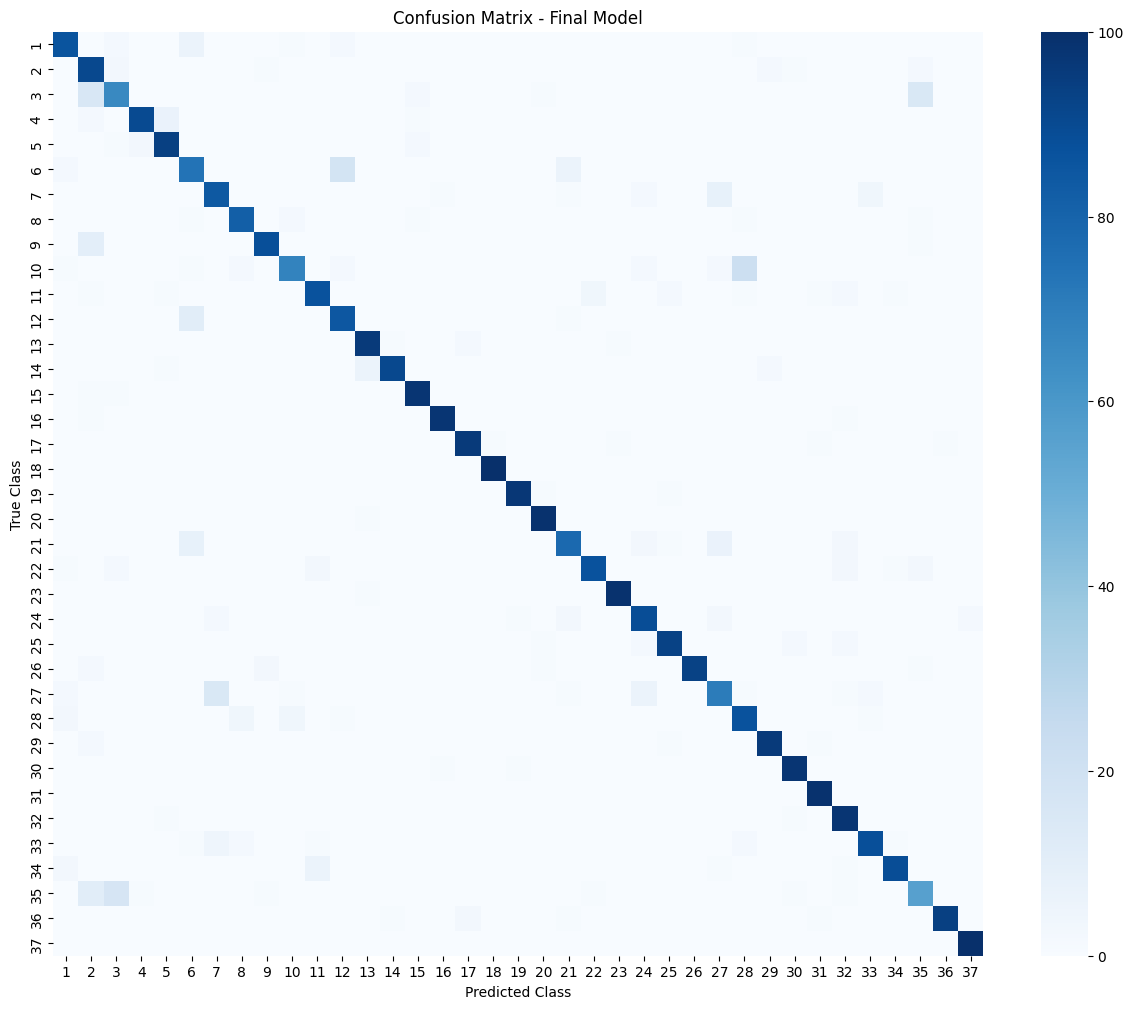

In [ ]:
cm = confusion_matrix(
    test_labels,
    y_pred
)

plt.figure(figsize=(15, 12))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=range(1, 38),
    yticklabels=range(1, 38)
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - Final Model")

plt.show()

In [ ]:
print(
    classification_report(
        test_labels,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        98
           1       0.66      0.91      0.77       100
           2       0.72      0.66      0.69       100
           3       0.96      0.90      0.93       100
           4       0.90      0.94      0.92       100
           5       0.73      0.74      0.73       100
           6       0.79      0.84      0.82       100
           7       0.91      0.93      0.92        88
           8       0.95      0.89      0.92        99
           9       0.89      0.68      0.77       100
          10       0.90      0.87      0.88       100
          11       0.79      0.88      0.83        97
          12       0.92      0.96      0.94       100
          13       0.98      0.91      0.94       100
          14       0.94      0.98      0.96       100
          15       0.98      0.98      0.98       100
          16       0.95      0.96      0.96       100
          17       0.99    

In [ ]:
final_model.save(
    "/content/final_mobilenetv2_model.keras"
)

print("Model saved successfully.")

Model saved successfully.


TensorFlow version: 2.20.0

Checking dataset...
Images: True
Train annotations: True
Test annotations: True

Training images: 3680
Training labels: 3680
Number of classes: 37

Test images: 3669
Test labels: 3669
Number of breed names: 7349


CONFIGURATION: C1_Baseline
Settings: {'learning_rate': 0.001, 'dropout': 0.0, 'batch_size': 32, 'optimizer': 'Adam', 'frozen': 'frozen'}


Configuration: C1_Baseline | Fold: 1
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 197ms/step - accuracy: 0.7079 - loss: 1.1457 - val_accuracy: 0.8750 - val_loss: 0.4115
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.9209 - loss: 0.2419 - val_accuracy: 0.8954 - val_loss: 0.3334
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.9647 - loss: 0.1339 - val_accuracy: 0.9117 - val_loss: 0.2936
Fold 1 Best Validation Accuracy: 91.17 %


Configuration: C1_Baseline | Fold: 2
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.7446 - loss: 1.0846 - val_accuracy: 0.8573 - val_loss: 0

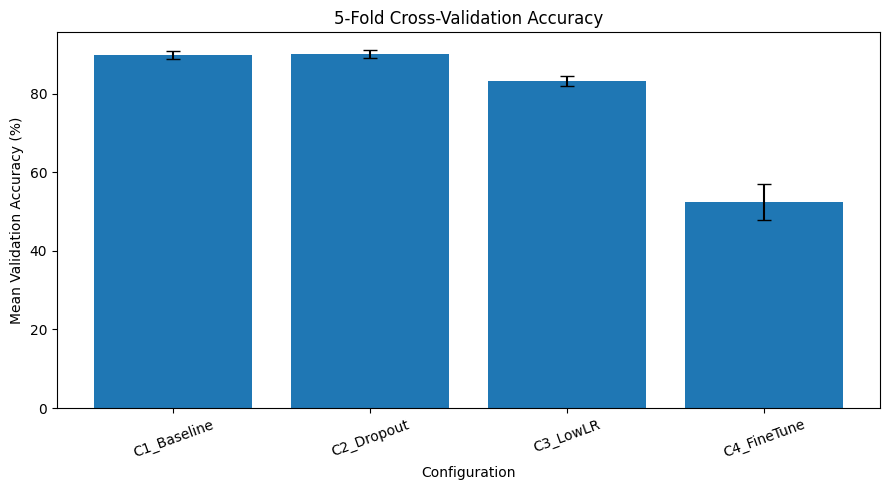



BEST CONFIGURATION
Configuration: C2_Dropout
Settings: {'learning_rate': 0.001, 'dropout': 0.5, 'batch_size': 32, 'optimizer': 'Adam', 'frozen': 'frozen'}
Mean CV Accuracy: 90.11 %
CV Standard Deviation: 0.98 %


TRAINING FINAL MODEL
Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.4997 - loss: 1.8738
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.8019 - loss: 0.6711
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.8668 - loss: 0.4389
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.8986 - loss: 0.3388
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.9098 - loss: 0.2830

Final training time: 60.66 seconds


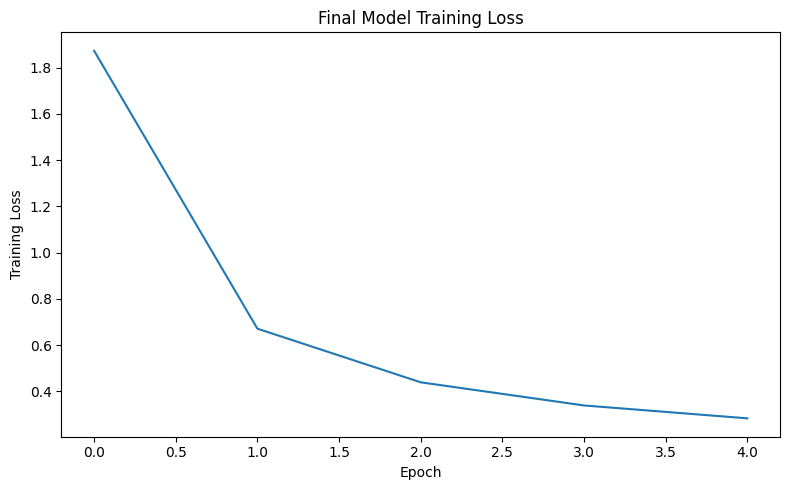



FINAL TEST EVALUATION
115/115 ━━━━━━━━━━━━━━━━━━━━ 25s 183ms/step - accuracy: 0.8842 - loss: 0.3452

Test Loss: 0.3452
Test Accuracy: 88.42 %
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step


FINAL METRICS
Accuracy: 88.42 %
Precision: 0.894
Recall: 0.8842
F1 Score: 0.8834


CLASSIFICATION REPORT


ValueError: Number of classes, 37, does not match size of target_names, 7349. Try specifying the labels parameter

In [ ]:
# ============================================================
# K-FOLD CROSS VALIDATION → BEST MODEL → FINAL EVALUATION
# MobileNetV2 - Oxford-IIIT Pet Dataset
# ============================================================

# ------------------------------------------------------------
# 1. IMPORTS
# ------------------------------------------------------------

import os
import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)


# ------------------------------------------------------------
# 2. DATASET PATHS
# ------------------------------------------------------------

DATA_DIR = "/content/oxford_pet"

image_dir = os.path.join(
    DATA_DIR,
    "images"
)

train_annotation_file = os.path.join(
    DATA_DIR,
    "annotations",
    "trainval.txt"
)

test_annotation_file = os.path.join(
    DATA_DIR,
    "annotations",
    "test.txt"
)

print("\nChecking dataset...")

print(
    "Images:",
    os.path.exists(image_dir)
)

print(
    "Train annotations:",
    os.path.exists(train_annotation_file)
)

print(
    "Test annotations:",
    os.path.exists(test_annotation_file)
)


# ------------------------------------------------------------
# 3. LOAD TRAINING FILE PATHS + LABELS
# ------------------------------------------------------------

train_files = []
train_labels = []

with open(train_annotation_file, "r") as f:

    for line in f:

        parts = line.strip().split()

        if len(parts) < 2:
            continue

        image_name = parts[0]
        class_id = int(parts[1])

        image_path = os.path.join(
            image_dir,
            image_name + ".jpg"
        )

        if os.path.exists(image_path):

            train_files.append(image_path)

            # Original labels are 1-37
            # Convert to 0-36
            train_labels.append(
                class_id - 1
            )


train_files = np.array(train_files)
train_labels = np.array(train_labels)


print("\nTraining images:", len(train_files))
print("Training labels:", len(train_labels))
print(
    "Number of classes:",
    len(np.unique(train_labels))
)


# ------------------------------------------------------------
# 4. LOAD TEST FILE PATHS + LABELS
# ------------------------------------------------------------

test_files = []
test_labels = []

with open(test_annotation_file, "r") as f:

    for line in f:

        parts = line.strip().split()

        if len(parts) < 2:
            continue

        image_name = parts[0]
        class_id = int(parts[1])

        image_path = os.path.join(
            image_dir,
            image_name + ".jpg"
        )

        if os.path.exists(image_path):

            test_files.append(image_path)

            test_labels.append(
                class_id - 1
            )


test_files = np.array(test_files)
test_labels = np.array(test_labels)


print("\nTest images:", len(test_files))
print("Test labels:", len(test_labels))


# ------------------------------------------------------------
# 5. LOAD CLASS / BREED NAMES
# ------------------------------------------------------------

breed_file = os.path.join(
    DATA_DIR,
    "annotations",
    "list.txt"
)

breeds = []

with open(breed_file, "r") as f:

    for line in f:

        line = line.strip()

        if not line:
            continue

        if line.startswith("#"):
            continue

        parts = line.split()

        if len(parts) >= 2:

            breeds.append(
                parts[0]
            )


print(
    "Number of breed names:",
    len(breeds)
)


# ------------------------------------------------------------
# 6. IMAGE PREPROCESSING
# ------------------------------------------------------------

IMG_SIZE = (224, 224)


def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.keras.applications.mobilenet_v2.preprocess_input(
        image
    )

    return image, label


# ------------------------------------------------------------
# 7. CREATE TF.DATA DATASET
# ------------------------------------------------------------

def create_dataset(
    files,
    labels,
    batch_size=32,
    shuffle=False
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            files,
            labels
        )
    )

    if shuffle:

        dataset = dataset.shuffle(
            buffer_size=min(
                len(files),
                1000
            ),
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(
        batch_size
    )

    # Keep this small because of RAM limitation
    dataset = dataset.prefetch(1)

    return dataset


# ------------------------------------------------------------
# 8. CREATE MOBILENETV2 MODEL
# ------------------------------------------------------------

NUM_CLASSES = 37


def create_mobilenet_model(
    dropout_rate=0.0,
    frozen="frozen"
):

    # Load pretrained MobileNetV2
    base_model = tf.keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )


    # ----------------------------------------
    # FREEZE / PARTIAL FINE-TUNING
    # ----------------------------------------

    if frozen == "frozen":

        base_model.trainable = False


    elif frozen == "partial":

        base_model.trainable = True

        # Freeze most layers
        for layer in base_model.layers[:-30]:

            layer.trainable = False


    # ----------------------------------------
    # CLASSIFICATION HEAD
    # ----------------------------------------

    inputs = tf.keras.Input(
        shape=(224, 224, 3)
    )

    x = base_model(
        inputs,
        training=False
    )

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu"
    )(x)


    # Dropout if required
    if dropout_rate > 0:

        x = tf.keras.layers.Dropout(
            dropout_rate
        )(x)


    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = tf.keras.Model(
        inputs,
        outputs
    )

    return model


# ------------------------------------------------------------
# 9. OPTIMIZER FUNCTION
# ------------------------------------------------------------

def get_optimizer(
    optimizer_name,
    learning_rate
):

    if optimizer_name == "SGD":

        return tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )


    elif optimizer_name == "Momentum":

        return tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )


    elif optimizer_name == "RMSProp":

        return tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )


    else:

        return tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )


# ------------------------------------------------------------
# 10. K-FOLD CONFIGURATIONS
# ------------------------------------------------------------
#
# These are the promising configurations that will be compared.
#
# C1 = Baseline
# C2 = Dropout
# C3 = Lower Learning Rate
# C4 = Fine-Tuning
#
# IMPORTANT:
# Only ONE model is kept in memory at a time.
# ------------------------------------------------------------

cv_configs = {

    "C1_Baseline": {

        "learning_rate": 0.001,

        "dropout": 0.0,

        "batch_size": 32,

        "optimizer": "Adam",

        "frozen": "frozen"
    },


    "C2_Dropout": {

        "learning_rate": 0.001,

        "dropout": 0.5,

        "batch_size": 32,

        "optimizer": "Adam",

        "frozen": "frozen"
    },


    "C3_LowLR": {

        "learning_rate": 0.0001,

        "dropout": 0.0,

        "batch_size": 32,

        "optimizer": "Adam",

        "frozen": "frozen"
    },


    "C4_FineTune": {

        "learning_rate": 0.00001,

        "dropout": 0.0,

        "batch_size": 32,

        "optimizer": "Adam",

        "frozen": "partial"
    }
}


# ------------------------------------------------------------
# 11. 5-FOLD CROSS VALIDATION
# ------------------------------------------------------------

N_SPLITS = 5

# Keep this small because you have RAM constraints.
# You can change to 5 if you have enough time/RAM.
EPOCHS_CV = 3


cv_results = []


skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)


for config_name, config in cv_configs.items():

    print("\n")
    print("=" * 70)

    print(
        "CONFIGURATION:",
        config_name
    )

    print(
        "Settings:",
        config
    )

    print("=" * 70)


    fold_accuracies = []

    fold_times = []


    # --------------------------------------------------------
    # FIVE FOLDS
    # --------------------------------------------------------

    for fold, (train_idx, val_idx) in enumerate(

        skf.split(
            train_files,
            train_labels
        ),

        start=1
    ):


        print("\n")
        print(
            "Configuration:",
            config_name,
            "| Fold:",
            fold
        )


        # ----------------------------------------------------
        # CLEAR OLD MODEL FROM RAM
        # ----------------------------------------------------

        tf.keras.backend.clear_session()

        gc.collect()


        # ----------------------------------------------------
        # SPLIT DATA
        # ----------------------------------------------------

        fold_train_files = train_files[
            train_idx
        ]

        fold_train_labels = train_labels[
            train_idx
        ]

        fold_val_files = train_files[
            val_idx
        ]

        fold_val_labels = train_labels[
            val_idx
        ]


        # ----------------------------------------------------
        # DATASETS
        # ----------------------------------------------------

        train_ds = create_dataset(

            fold_train_files,

            fold_train_labels,

            batch_size=config["batch_size"],

            shuffle=True
        )


        val_ds = create_dataset(

            fold_val_files,

            fold_val_labels,

            batch_size=config["batch_size"],

            shuffle=False
        )


        # ----------------------------------------------------
        # MODEL
        # ----------------------------------------------------

        model = create_mobilenet_model(

            dropout_rate=config["dropout"],

            frozen=config["frozen"]
        )


        # ----------------------------------------------------
        # OPTIMIZER
        # ----------------------------------------------------

        optimizer = get_optimizer(

            config["optimizer"],

            config["learning_rate"]
        )


        # ----------------------------------------------------
        # COMPILE
        # ----------------------------------------------------

        model.compile(

            optimizer=optimizer,

            loss="sparse_categorical_crossentropy",

            metrics=["accuracy"]
        )


        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        start_time = time.time()


        history = model.fit(

            train_ds,

            validation_data=val_ds,

            epochs=EPOCHS_CV,

            verbose=1
        )


        elapsed_time = (
            time.time()
            -
            start_time
        )


        # ----------------------------------------------------
        # BEST VALIDATION ACCURACY
        # ----------------------------------------------------

        best_fold_accuracy = max(

            history.history[
                "val_accuracy"
            ]
        )


        fold_accuracies.append(
            best_fold_accuracy
        )


        fold_times.append(
            elapsed_time
        )


        print(
            "Fold",
            fold,
            "Best Validation Accuracy:",
            round(
                best_fold_accuracy * 100,
                2
            ),
            "%"
        )


        # ----------------------------------------------------
        # DELETE MODEL IMMEDIATELY
        # ----------------------------------------------------

        del model

        del history

        del train_ds

        del val_ds

        gc.collect()

        tf.keras.backend.clear_session()


    # --------------------------------------------------------
    # MEAN + STANDARD DEVIATION
    # --------------------------------------------------------

    mean_accuracy = np.mean(
        fold_accuracies
    )

    std_accuracy = np.std(
        fold_accuracies
    )

    mean_time = np.mean(
        fold_times
    )


    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    cv_results.append({

        "Configuration":
        config_name,

        "Fold 1":
        fold_accuracies[0] * 100,

        "Fold 2":
        fold_accuracies[1] * 100,

        "Fold 3":
        fold_accuracies[2] * 100,

        "Fold 4":
        fold_accuracies[3] * 100,

        "Fold 5":
        fold_accuracies[4] * 100,

        "Mean Accuracy":
        mean_accuracy * 100,

        "Std Deviation":
        std_accuracy * 100,

        "Mean Time":
        mean_time
    })


    print("\n")
    print(
        config_name,
        "Mean Accuracy:",
        round(
            mean_accuracy * 100,
            2
        ),
        "%"
    )

    print(
        config_name,
        "Std:",
        round(
            std_accuracy * 100,
            2
        ),
        "%"
    )


# ------------------------------------------------------------
# 12. K-FOLD RESULTS TABLE
# ------------------------------------------------------------

cv_df = pd.DataFrame(
    cv_results
)


print("\n")
print("=" * 70)
print("5-FOLD CROSS VALIDATION RESULTS")
print("=" * 70)

print(
    cv_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 13. PLOT — K-FOLD ACCURACY
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)


plt.bar(

    cv_df["Configuration"],

    cv_df["Mean Accuracy"],

    yerr=cv_df["Std Deviation"],

    capsize=5
)


plt.xlabel(
    "Configuration"
)

plt.ylabel(
    "Mean Validation Accuracy (%)"
)

plt.title(
    "5-Fold Cross-Validation Accuracy"
)


plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 14. SELECT BEST CONFIGURATION
# ------------------------------------------------------------

best_index = cv_df[
    "Mean Accuracy"
].idxmax()


best_config_name = cv_df.loc[
    best_index,
    "Configuration"
]


best_config = cv_configs[
    best_config_name
]


print("\n")
print("=" * 70)
print("BEST CONFIGURATION")
print("=" * 70)


print(
    "Configuration:",
    best_config_name
)


print(
    "Settings:",
    best_config
)


print(
    "Mean CV Accuracy:",
    round(
        cv_df.loc[
            best_index,
            "Mean Accuracy"
        ],
        2
    ),
    "%"
)


print(
    "CV Standard Deviation:",
    round(
        cv_df.loc[
            best_index,
            "Std Deviation"
        ],
        2
    ),
    "%"
)


# ------------------------------------------------------------
# 15. CLEAR MEMORY BEFORE FINAL TRAINING
# ------------------------------------------------------------

tf.keras.backend.clear_session()

gc.collect()


# ------------------------------------------------------------
# 16. CREATE FINAL MODEL
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("TRAINING FINAL MODEL")
print("=" * 70)


final_model = create_mobilenet_model(

    dropout_rate=best_config["dropout"],

    frozen=best_config["frozen"]
)


# ------------------------------------------------------------
# 17. FINAL OPTIMIZER
# ------------------------------------------------------------

final_optimizer = get_optimizer(

    best_config["optimizer"],

    best_config["learning_rate"]
)


# ------------------------------------------------------------
# 18. COMPILE FINAL MODEL
# ------------------------------------------------------------

final_model.compile(

    optimizer=final_optimizer,

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


# ------------------------------------------------------------
# 19. FULL TRAINING DATASET
# ------------------------------------------------------------

full_train_ds = create_dataset(

    train_files,

    train_labels,

    batch_size=best_config["batch_size"],

    shuffle=True
)


# ------------------------------------------------------------
# 20. TRAIN FINAL MODEL
# ------------------------------------------------------------

FINAL_EPOCHS = 5


start_time = time.time()


final_history = final_model.fit(

    full_train_ds,

    epochs=FINAL_EPOCHS,

    verbose=1
)


final_training_time = (
    time.time()
    -
    start_time
)


print(
    "\nFinal training time:",
    round(
        final_training_time,
        2
    ),
    "seconds"
)


# ------------------------------------------------------------
# 21. PLOT FINAL TRAINING LOSS
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    final_history.history["loss"]
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Loss"
)

plt.title(
    "Final Model Training Loss"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 22. CREATE TEST DATASET
# ------------------------------------------------------------
#
# IMPORTANT:
# The test set has NOT been used during K-Fold selection.
# We use it only now for final evaluation.
# ------------------------------------------------------------

test_ds = create_dataset(

    test_files,

    test_labels,

    batch_size=32,

    shuffle=False
)


# ------------------------------------------------------------
# 23. FINAL TEST EVALUATION
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("FINAL TEST EVALUATION")
print("=" * 70)


test_loss, test_accuracy = final_model.evaluate(

    test_ds,

    verbose=1
)


print(
    "\nTest Loss:",
    round(
        test_loss,
        4
    )
)


print(
    "Test Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)


# ------------------------------------------------------------
# 24. PREDICTIONS
# ------------------------------------------------------------

probabilities = final_model.predict(

    test_ds,

    verbose=1
)


predictions = np.argmax(

    probabilities,

    axis=1
)


true_labels = test_labels


# ------------------------------------------------------------
# 25. PRECISION / RECALL / F1
# ------------------------------------------------------------

precision = precision_score(

    true_labels,

    predictions,

    average="weighted",

    zero_division=0
)


recall = recall_score(

    true_labels,

    predictions,

    average="weighted",

    zero_division=0
)


f1 = f1_score(

    true_labels,

    predictions,

    average="weighted",

    zero_division=0
)


print("\n")
print("=" * 70)
print("FINAL METRICS")
print("=" * 70)


print(
    "Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)


print(
    "Precision:",
    round(
        precision,
        4
    )
)


print(
    "Recall:",
    round(
        recall,
        4
    )
)


print(
    "F1 Score:",
    round(
        f1,
        4
    )
)


# ------------------------------------------------------------
# 26. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


report = classification_report(

    true_labels,

    predictions,

    target_names=breeds,

    zero_division=0
)


print(
    report
)


# ------------------------------------------------------------
# 27. CONFUSION MATRIX
# ------------------------------------------------------------
#
# This is generated from the FINAL MODEL predictions
# on the untouched TEST SET.
# ------------------------------------------------------------

cm = confusion_matrix(

    true_labels,

    predictions
)


plt.figure(

    figsize=(16, 14)
)


sns.heatmap(

    cm,

    cmap="Blues",

    xticklabels=breeds,

    yticklabels=breeds,

    annot=False
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    "Confusion Matrix - Final MobileNetV2 Model"
)


plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 28. NUMBER OF PARAMETERS
# ------------------------------------------------------------

number_of_parameters = (

    final_model.count_params()

)


print(
    "\nNumber of Parameters:",
    number_of_parameters
)


# ------------------------------------------------------------
# 29. FINAL RESULTS TABLE
# ------------------------------------------------------------

final_results = pd.DataFrame({

    "Metric": [

        "Best Configuration",

        "Mean CV Accuracy (%)",

        "CV Standard Deviation (%)",

        "Test Accuracy (%)",

        "Precision",

        "Recall",

        "F1 Score",

        "Training Time (seconds)",

        "Number of Parameters"

    ],


    "Value": [

        best_config_name,

        round(
            cv_df.loc[
                best_index,
                "Mean Accuracy"
            ],
            2
        ),

        round(
            cv_df.loc[
                best_index,
                "Std Deviation"
            ],
            2
        ),

        round(
            test_accuracy * 100,
            2
        ),

        round(
            precision,
            4
        ),

        round(
            recall,
            4
        ),

        round(
            f1,
            4
        ),

        round(
            final_training_time,
            2
        ),

        number_of_parameters
    ]

})


print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)


print(
    final_results.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 30. SAVE FINAL MODEL
# ------------------------------------------------------------

final_model.save(
    "/content/final_mobilenetv2_model.keras"
)


print("\nFinal model saved successfully.")


# ------------------------------------------------------------
# 31. CLEANUP
# ------------------------------------------------------------

del probabilities
del test_ds
del full_train_ds

gc.collect()

print("\nDone!")

In [ ]:
# ============================================================
# CORRECT 37 BREED NAMES
# ============================================================

# Oxford-IIIT Pet breed names
breeds = [
    "Abyssinian",
    "american_bulldog",
    "american_pit_bull_terrier",
    "basset_hound",
    "beagle",
    "Bengal",
    "Birman",
    "Bombay",
    "boxer",
    "British_Shorthair",
    "chihuahua",
    "Egyptian_Mau",
    "english_cocker_spaniel",
    "english_setter",
    "german_shorthaired",
    "great_pyrenees",
    "havanese",
    "japanese_chin",
    "keeshond",
    "leonberger",
    "Maine_Coon",
    "miniature_pinscher",
    "Newfoundland",
    "Persian",
    "pomeranian",
    "pug",
    "Ragdoll",
    "Russian_Blue",
    "saint_bernard",
    "samoyed",
    "scottish_terrier",
    "shiba_inu",
    "Siamese",
    "staffordshire_bull_terrier",
    "wheaten_terrier",
    "yorkshire_terrier",
    "american_staffordshire_terrier"
]

print("Number of breed names:", len(breeds))

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

report = classification_report(
    true_labels,
    predictions,
    labels=np.arange(37),
    target_names=breeds,
    zero_division=0
)

print(report)

Number of breed names: 37


CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                    Abyssinian       0.91      0.87      0.89        98
              american_bulldog       0.83      0.68      0.75       100
     american_pit_bull_terrier       0.84      0.49      0.62       100
                  basset_hound       0.99      0.87      0.93       100
                        beagle       0.91      0.98      0.94       100
                        Bengal       0.73      0.80      0.76       100
                        Birman       0.89      0.55      0.68       100
                        Bombay       0.89      0.91      0.90        88
                         boxer       0.82      0.90      0.86        99
             British_Shorthair       0.93      0.66      0.77       100
                     chihuahua       0.89      0.88      0.88       100
                  Egyptian_Mau       0.87      0.80      0.83        97
        engli

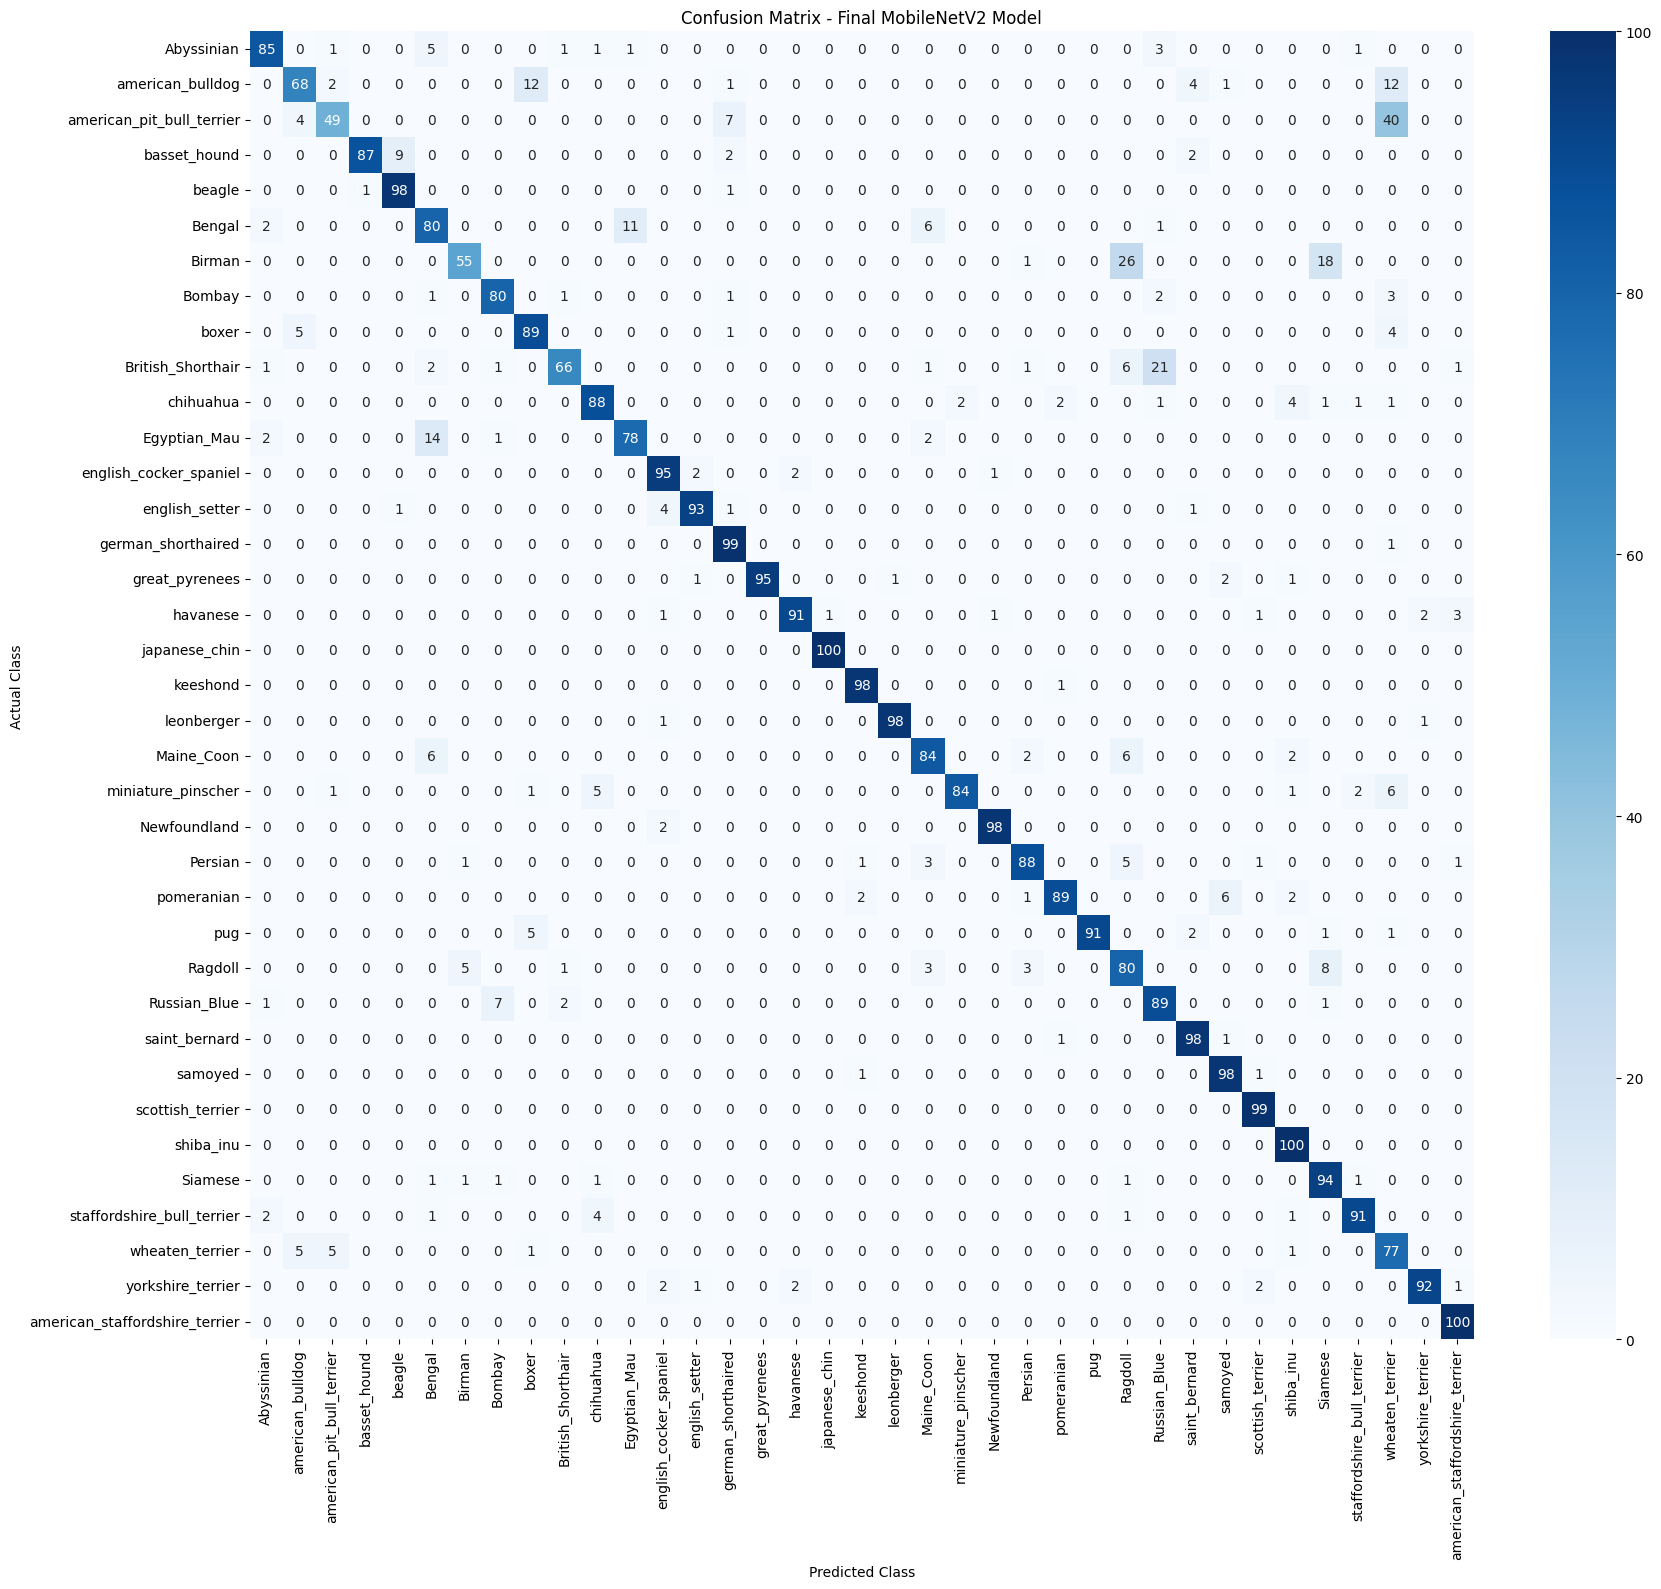

In [ ]:
cm = confusion_matrix(
    true_labels,
    predictions,
    labels=np.arange(37)
)

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="d",
    xticklabels=breeds,
    yticklabels=breeds
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Confusion Matrix - Final MobileNetV2 Model"
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Total misclassified images: 425


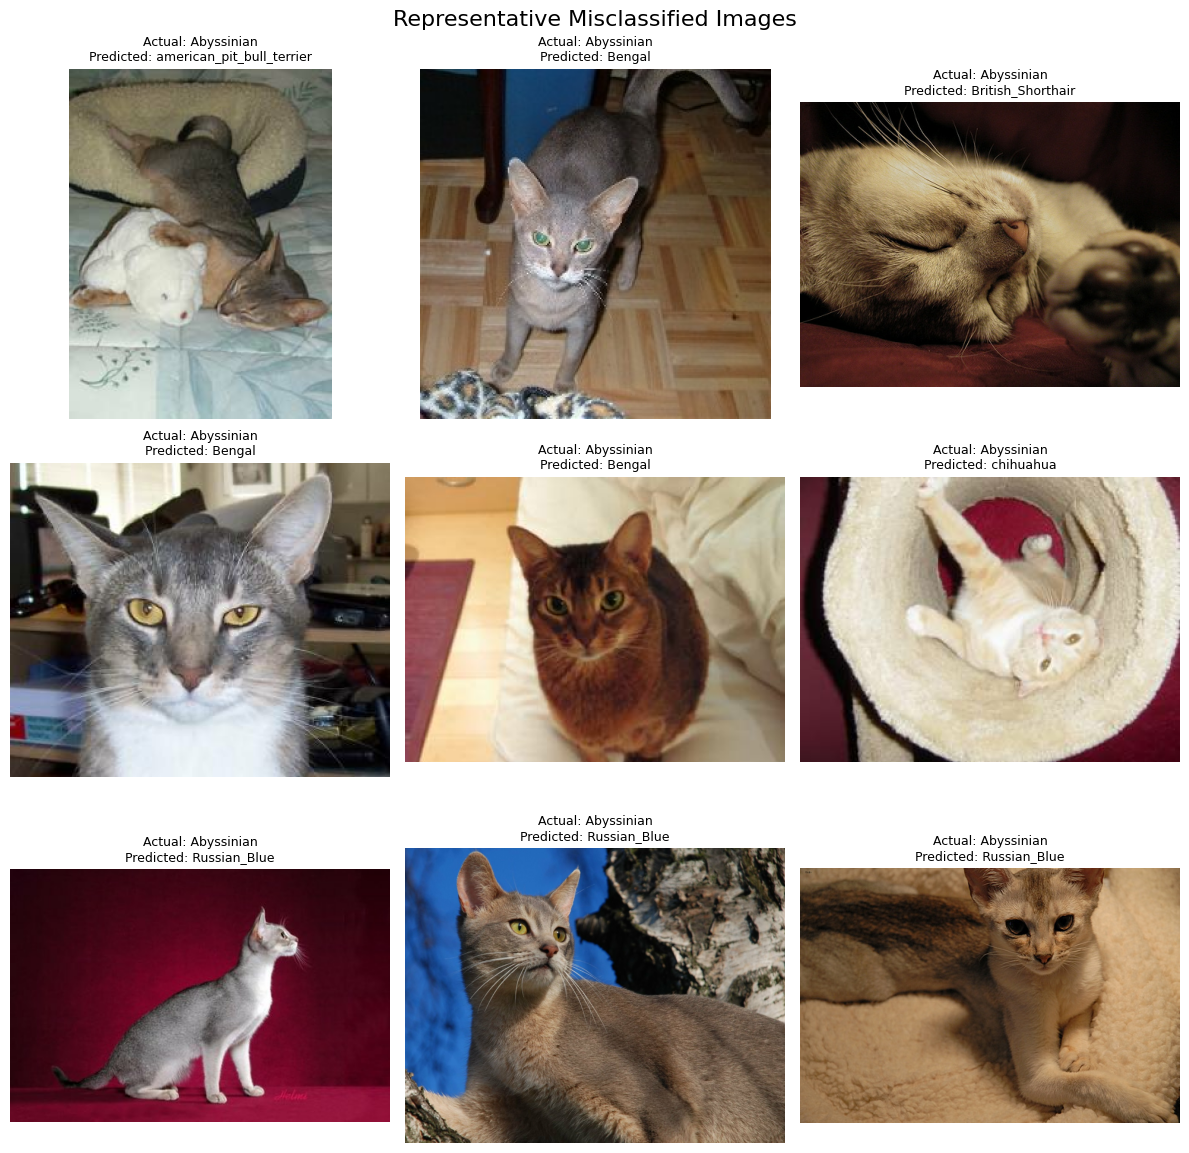

In [ ]:
# ============================================================
# PLOT 15: MISCLASSIFIED IMAGES
# ============================================================

import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Find incorrectly classified images
wrong_indices = np.where(
    true_labels != predictions
)[0]

print("Total misclassified images:", len(wrong_indices))


# Number of images to display
num_images = min(9, len(wrong_indices))

plt.figure(figsize=(12, 12))

for i in range(num_images):

    idx = wrong_indices[i]

    # Read image
    image = tf.io.read_file(test_files[idx])

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Convert to numpy for display
    image = image.numpy().astype("uint8")

    actual_class = breeds[true_labels[idx]]
    predicted_class = breeds[predictions[idx]]

    plt.subplot(3, 3, i + 1)

    plt.imshow(image)

    plt.title(
        "Actual: " + actual_class +
        "\nPredicted: " + predicted_class,
        fontsize=9
    )

    plt.axis("off")

plt.suptitle(
    "Representative Misclassified Images",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "/content/plot15_misclassified_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()